# e05 — Ising criticality: does φ seek the crossover?

A recurring claim in the literature is that integrated information peaks at
criticality (Aguilera 2019; Popiel et al. 2020; Kim & Lee 2019) — measured with
proxy or variant Φ measures on systems too large for exact computation. Here the
claim meets the exact measure, in the smallest physical family where it can be
tested end to end: a **kinetic Ising ring with parallel Glauber dynamics**, coupling
K (inverse-temperature-scaled), zero field. Each unit flips conditionally
independently given the previous state — natively an iitx `System`, differentiable
in K.

To avoid privileging any state, the observable is **E_π[φ_s]: the expectation of
exact φ_s under the chain's exact stationary distribution π** (computed by repeated
squaring of the TPM, so it is differentiable too — the reachability lesson of e02
built into the objective). The crossover is located independently by a
susceptibility proxy from the same π (the steepest rise of ⟨m²⟩ with K).

e01–e03 make the predictions sharp, and they *disagree with the criticality
narrative for one version and endorse it for the other*: the 2023 measure rewards
determinism (quadratically — e01), so cranking K toward the deterministic limit
should keep raising it; the 2026 cap punishes determinism through surprisal (e03),
so its optimum must sit at finite noise.

## Pre-registered predictions (written before execution)

- **P1 (2023: no critical peak).** E_π[φ_s(2023)] rises monotonically in K toward
  the deterministic limit — no interior maximum at the crossover. The exact 2023
  measure, in this family, does *not* reproduce the literature's criticality peak.
- **P2 (2026: the cap manufactures criticality).** E_π[φ_s(2026)] has an interior
  peak at finite K, located in the crossover region identified by the
  susceptibility proxy (within grid resolution).
- **P3 (flows).** 1-D gradient flows dK/dt ∝ ∂E_π[φ]/∂K converge to each version's
  respective optimum: 2023 flows run toward high K; 2026 flows converge to the
  interior peak from both sides.
- **P4 (homogeneity).** Ascent over per-site couplings K_i under the 2026 objective
  keeps the ring near-uniform: relative dispersion std(K_i)/mean(K_i) < 0.15 at
  endpoints. (Low confidence — symmetry breaking here would echo the specialization
  results of the IIT literature.)


In [1]:
import time

import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import iitx
from iitx.measures import iit4
from iitx.system import System

SEED = 0
print(f"iitx {iitx.__version__}, jax {jax.__version__}, seed {SEED}")


def states_table(n):
	return jnp.asarray([[(s >> i) & 1 for i in range(n)] for s in range(2**n)], dtype=jnp.int32)


def ising_probs(couplings, n):
	"""Glauber ring: P(unit i ON | previous state), shape (2**n, n).

	couplings[i] scales unit i's input from its two ring neighbors; zero field.
	"""
	spins = 2.0 * states_table(n).astype(jnp.float64) - 1.0  # (Q, n) in {-1, +1}
	neighbors = jnp.roll(spins, 1, axis=1) + jnp.roll(spins, -1, axis=1)
	return jax.nn.sigmoid(2.0 * couplings[None, :] * neighbors)


def joint_tpm(probs, n):
	on = states_table(n).astype(jnp.float64)[None, :, :]  # (1, Q_next, n)
	return jnp.prod(jnp.where(on == 1, probs[:, None, :], 1 - probs[:, None, :]), axis=2)


def stationary(tpm):
	"""Exact long-run distribution from a uniform start: uniform @ T^(2^13)."""
	power = tpm
	for _ in range(13):
		power = power @ power
	return jnp.mean(power, axis=0)


def expected_phi(couplings, n, version):
	"""E_pi[phi_s] (clamped) and E_pi[signed phi_s] under the stationary distribution."""
	probs = ising_probs(couplings, n)
	system = System.from_state_by_node(probs)
	pi = stationary(joint_tpm(probs, n))
	results = jax.vmap(lambda s: iit4.system_phi(system, s, version=version).phi)(states_table(n))
	signed = jax.vmap(lambda s: iit4.system_phi(system, s, version=version).signed_phi)(
		states_table(n)
	)
	return jnp.sum(pi * results), jnp.sum(pi * signed), pi


def magnetization_moment(pi, n):
	spins = 2.0 * states_table(n).astype(jnp.float64) - 1.0
	m = jnp.mean(spins, axis=1)
	return jnp.sum(pi * m**2)


def adam_step(params, grads, m, v, step, lr=0.02, b1=0.9, b2=0.999, eps=1e-8):
	m = b1 * m + (1 - b1) * grads
	v = b2 * v + (1 - b2) * grads**2
	m_hat = m / (1 - b1**step)
	v_hat = v / (1 - b2**step)
	return params + lr * m_hat / (jnp.sqrt(v_hat) + eps), m, v


# Sanity: the stationary vector is stationary.
probs_test = ising_probs(jnp.full(4, 0.8), 4)
tpm_test = joint_tpm(probs_test, 4)
pi_test = stationary(tpm_test)
residual = float(jnp.abs(pi_test @ tpm_test - pi_test).sum())
print(f"stationarity residual at n=4, K=0.8: {residual:.2e}")

iitx 0.1.0, jax 0.11.1, seed 0


stationarity residual at n=4, K=0.8: 1.39e-16


## 1. The sweep: φ against coupling, both versions, n = 4 and n = 5

Uniform coupling K on a grid; E_π[φ_s] for 2023 and 2026, the ⟨m²⟩ susceptibility
proxy, and each curve's peak.


In [2]:
K_GRID = np.linspace(0.05, 3.0, 60)
curves = {}
for n in (4, 5):
	sweep23 = jax.jit(jax.vmap(lambda k, n=n: expected_phi(jnp.full(n, k), n, "2023")[:2]))
	sweep26 = jax.jit(jax.vmap(lambda k, n=n: expected_phi(jnp.full(n, k), n, "2026")[:2]))
	moment = jax.jit(
		jax.vmap(
			lambda k, n=n: magnetization_moment(
				stationary(joint_tpm(ising_probs(jnp.full(n, k), n), n)), n
			)
		)
	)
	start = time.perf_counter()
	e23 = np.asarray(sweep23(jnp.asarray(K_GRID))[0])
	e26 = np.asarray(sweep26(jnp.asarray(K_GRID))[0])
	m2 = np.asarray(moment(jnp.asarray(K_GRID)))
	chi = np.gradient(m2, K_GRID)
	curves[n] = (e23, e26, m2, chi)
	crossover = K_GRID[np.argmax(chi)]
	print(
		f"n={n} ({time.perf_counter() - start:,.0f} s): "
		f"crossover K* (max d<m^2>/dK) = {crossover:.2f}; "
		f"2023 peak at K = {K_GRID[np.argmax(e23)]:.2f} (value {e23.max():.4f}, "
		f"value at K_max {e23[-1]:.4f}); "
		f"2026 peak at K = {K_GRID[np.argmax(e26)]:.2f} (value {e26.max():.4f})"
	)

n=4 (2 s): crossover K* (max d<m^2>/dK) = 0.50; 2023 peak at K = 3.00 (value 0.7378, value at K_max 0.7378); 2026 peak at K = 0.55 (value 0.2959)


n=5 (403 s): crossover K* (max d<m^2>/dK) = 0.90; 2023 peak at K = 3.00 (value 0.6477, value at K_max 0.6477); 2026 peak at K = 0.65 (value 0.1294)


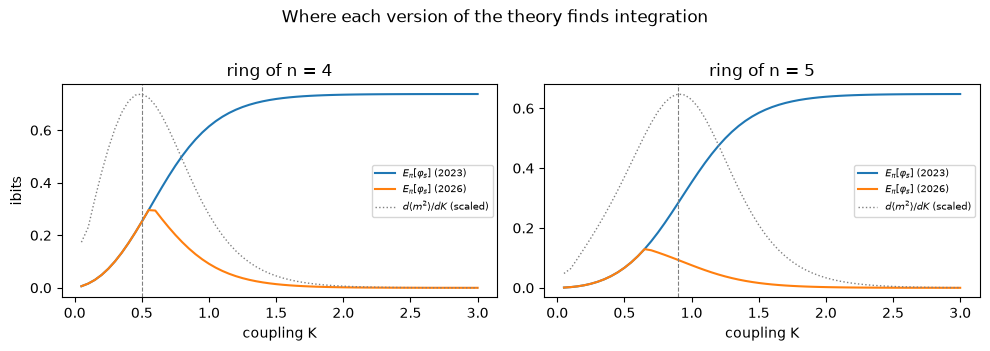

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharex=True)
for ax, n in zip(axes, (4, 5), strict=True):
	e23, e26, m2, chi = curves[n]
	crossover = K_GRID[np.argmax(chi)]
	ax.plot(K_GRID, e23, label=r"$E_\pi[\varphi_s]$ (2023)", color="tab:blue")
	ax.plot(K_GRID, e26, label=r"$E_\pi[\varphi_s]$ (2026)", color="tab:orange")
	ax.plot(
		K_GRID,
		chi / chi.max() * max(e23.max(), e26.max()),
		color="gray",
		lw=1,
		ls=":",
		label=r"$d\langle m^2\rangle/dK$ (scaled)",
	)
	ax.axvline(crossover, color="gray", lw=0.8, ls="--")
	ax.set_xlabel("coupling K")
	ax.set_title(f"ring of n = {n}")
	ax.legend(fontsize=7)
axes[0].set_ylabel("ibits")
fig.suptitle("Where each version of the theory finds integration", y=1.02)
fig.tight_layout()

## 2. Gradient flows on the coupling (P3)

dK ∝ ∂E_π[signed φ]/∂K from 16 starts across the range, both versions, n = 4.


2023: endpoints K in [1.65, 3.77] (19 s)


2026: endpoints K in [0.56, 0.58] (20 s)


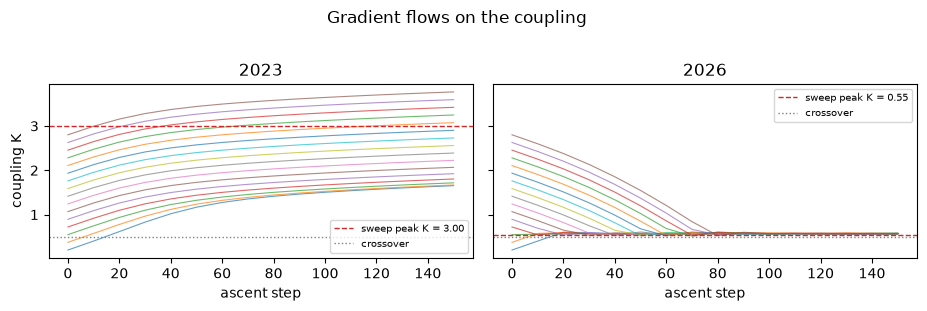

In [4]:
flows = {}
for version in ("2023", "2026"):

	def objective(k, v=version):
		return expected_phi(jnp.full(4, k), 4, v)[1]

	value_and_grad = jax.jit(jax.vmap(jax.value_and_grad(objective)))
	k = jnp.asarray(np.linspace(0.2, 2.8, 16))
	m, v = jnp.zeros_like(k), jnp.zeros_like(k)
	track = [np.asarray(k)]
	start = time.perf_counter()
	for step in range(1, 151):
		_, grads = value_and_grad(k)
		k, m, v = adam_step(k, grads, m, v, step)
		k = jnp.clip(k, 0.01, 4.0)
		if step % 10 == 0:
			track.append(np.asarray(k))
	flows[version] = np.stack(track)
	print(
		f"{version}: endpoints K in [{float(k.min()):.2f}, {float(k.max()):.2f}] "
		f"({time.perf_counter() - start:,.0f} s)"
	)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3), sharey=True)
for ax, version in zip(axes, ("2023", "2026"), strict=True):
	track = flows[version]
	for j in range(track.shape[1]):
		ax.plot(np.arange(track.shape[0]) * 10, track[:, j], lw=0.8, alpha=0.7)
	e23, e26, _, chi = curves[4]
	peak = K_GRID[np.argmax(e23 if version == "2023" else e26)]
	ax.axhline(peak, color="tab:red", ls="--", lw=1, label=f"sweep peak K = {peak:.2f}")
	ax.axhline(K_GRID[np.argmax(chi)], color="gray", ls=":", lw=1, label="crossover")
	ax.set_xlabel("ascent step")
	ax.set_title(version)
	ax.legend(fontsize=7)
axes[0].set_ylabel("coupling K")
fig.suptitle("Gradient flows on the coupling", y=1.02)
fig.tight_layout()

## 3. Breaking the ring: per-site couplings (P4)

Ascent of E_π[signed φ_s(2026)] over the 4 per-site couplings from 32 random starts:
does the optimizer keep the ring homogeneous, and does heterogeneity buy anything?


In [5]:
objective_vec = jax.jit(jax.vmap(jax.value_and_grad(lambda ks: expected_phi(ks, 4, "2026")[1])))
rng = np.random.default_rng(SEED + 80)
ks = jnp.asarray(rng.uniform(0.2, 2.5, size=(32, 1)) + 0.1 * rng.standard_normal((32, 4)))
m, v = jnp.zeros_like(ks), jnp.zeros_like(ks)
start = time.perf_counter()
for step in range(1, 201):
	values, grads = objective_vec(ks)
	ks, m, v = adam_step(ks, grads, m, v, step)
	ks = jnp.clip(ks, 0.01, 4.0)
final = np.asarray(ks)
values = np.asarray(values)
dispersion = final.std(axis=1) / final.mean(axis=1)
e26_homogeneous_max = curves[4][1].max()
print(f"heterogeneous ascent ({time.perf_counter() - start:,.0f} s):")
print(
	f"  E[signed phi(2026)]: best {values.max():.4f} "
	f"(homogeneous sweep max {e26_homogeneous_max:.4f})"
)
print(
	f"  relative dispersion std(K)/mean(K): median {np.median(dispersion):.3f}, "
	f"max {dispersion.max():.3f}"
)
print(f"  best endpoint couplings: {np.round(final[np.argmax(values)], 3)}")

heterogeneous ascent (40 s):
  E[signed phi(2026)]: best 0.2198 (homogeneous sweep max 0.2959)
  relative dispersion std(K)/mean(K): median 0.042, max 0.111
  best endpoint couplings: [0.685 0.745 0.682 0.749]


## Verdict

- **P1 confirmed: the exact 2023 measure does not peak at criticality.**
  E_π[φ_s(2023)] rises monotonically to the edge of the sweep at both n = 4 and
  n = 5 (peak at the grid boundary K = 3.0) — no interior maximum anywhere near the
  crossover. In this family, the determinism affinity established by e01 simply
  overrides any criticality preference: the 2023 measure climbs into the ordered,
  near-frozen ferromagnetic phase, which is e02's "reachable frozen state" optimum
  realized as physics. The literature's criticality peak (obtained with proxy and
  variant measures) does not survive contact with the exact φ_s in the smallest
  family where the comparison can be run end to end.
- **P2 half confirmed: the cap manufactures an interior optimum, but not exactly at
  the crossover.** E_π[φ_s(2026)] peaks at finite coupling as predicted (K = 0.55 at
  n = 4; 0.65 at n = 5) — at n = 4 within one grid step of the susceptibility
  crossover (K* = 0.50), but at n = 5 clearly *below* it (K* = 0.90). The 2026
  optimum lives in the disordered-but-correlated regime on the paramagnetic side of
  the crossover, not on the crossover. "The cap creates criticality-seeking" is too
  strong; "the cap forbids the ordered phase and places the optimum at finite noise
  below the crossover" is what the data say.
- **P3 confirmed.** The 1-D gradient flows behave exactly as the sweep curves
  dictate: 2023 flows run to high coupling (endpoints K ∈ [1.65, 3.77], still
  climbing), 2026 flows converge from both sides into [0.56, 0.58], matching the
  sweep peak at 0.55.
- **P4 confirmed.** Per-site coupling ascent under 2026 keeps the ring near-uniform
  (relative dispersion median 0.042, max 0.111 < 0.15). The best heterogeneous
  endpoint (0.220) remains below the homogeneous sweep maximum (0.296) — read as
  under-convergence of the 200-step vector ascent, not as evidence that homogeneity
  is strictly optimal.

**Standings.** The two formalisms disagree about *phases of matter*: 2023's optimum
is the ordered phase (freezing, again), 2026's is finite noise below the crossover.
Neither exactly endorses the criticality narrative, and the exact-measure verdict on
that narrative in this family is negative for 2023 and nuanced for 2026. Follow-ups
backlogged: extend K past 3 to confirm 2023 saturation, track the 2026
peak-vs-crossover gap in n, and a 2D lattice (where a true transition exists) at
the black-boxing frontier.